<div style="font-family: Calibri; background-color: #ccd5ae; padding: 10px 10px;">
    <h2>Ensemble - XGBoost</h2> With scale_pos_weight
</div>

In [104]:
import pandas as pd
import numpy as np
import warnings
from sklearn import set_config
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from scripts.plot_tetha import plot_model
import seaborn as sns
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, make_scorer, confusion_matrix, fbeta_score
from sklearn.pipeline import Pipeline

In [105]:
%load_ext autoreload
%autoreload 2
from scripts.scores import calc_predict_proba, calc_scores, confusion_matrix_display, print_evaluation
from scripts.decision_tree import determine_parameter

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [106]:
warnings.filterwarnings("ignore") 
set_config(display='diagram')
pd.options.display.precision=3
pd.set_option('display.float_format', lambda x: '%.3f' % x)

<div style="font-family: Calibri; background-color: #faedcd; padding: 5px;">
    <h2>1. Loading Train and Test dataset</h2>
</div>

In [107]:
df = pd.read_csv("data/train.csv" )
df.shape

(255347, 18)

In [108]:
X = df.drop(columns=['Default', 'LoanID', 'DTIRatio', 'CreditScore'])
y = df['Default']

In [109]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(X_train.shape, X_test.shape,  y_train.shape, y_test.shape)

(204277, 14) (51070, 14) (204277,) (51070,)


<hr>
<div style="font-family: Calibri; background-color: #faedcd; padding: 5px 5px 5px 5px;">
    <h2>2. Column Transformation</h2>
</div>

In [110]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures

<div style="font-family: Calibri; font-size: 18px; background-color: #fefae0; padding: 3px 3px 3px 10px;">
    <h3>Univariate Analysis - Conclusion (Recap)</h3>    
    <ul>
            <li>HasCoSigner, HasDependents, HasMortgage are binary fields</li>
            <li>Education, EmploymentType, LoanPurpose, MaritalStatus are categorical data</li>
    </ul>        
    <h4>Transformation is done external to pipeline to avoid the redundent step In GridSearchCV
    </h4>
</div>

In [111]:
numerical_features = X_train.select_dtypes(exclude='object').columns.tolist()
categorial_features = X_train.select_dtypes(include='object').columns.tolist()

In [112]:
transformer = ColumnTransformer(
    [
        ('Binary', OneHotEncoder(drop='if_binary'), ['HasCoSigner', 'HasDependents', 'HasMortgage']),
        ('multi_category', OneHotEncoder(),  ['Education', 'EmploymentType', 'MaritalStatus']),
        ('Loan_category', OneHotEncoder(categories = [['Business', 'Home']], handle_unknown='ignore'), ['LoanPurpose']), 
    ], remainder=MinMaxScaler()
)

In [113]:
X_train = transformer.fit_transform(X_train)

In [114]:
X_test = transformer.transform(X_test)

<hr>
<div style="font-family: Calibri; background-color: #faedcd; padding: 5px 5px 5px 5px;">
    <h2>3. XGBClassifier</h2>
</div>

In [115]:
import xgboost as xgb

In [116]:
# Compute scale_pos_weight
scale_pos_weight = sum(y_train == 0) / sum(y_train == 1)
print(f"Calculated scale_pos_weight: {scale_pos_weight:.2f}")

Calculated scale_pos_weight: 7.60


In [117]:
scoring=make_scorer(fbeta_score, beta=2, pos_label=1)

model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,  
    objective="binary:logistic",
    eval_metric=scoring,
    use_label_encoder=False,
    random_state=42
)

In [118]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False,
              eval_metric=make_scorer(fbeta_score, response_method='predict', beta=2, pos_label=1),
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

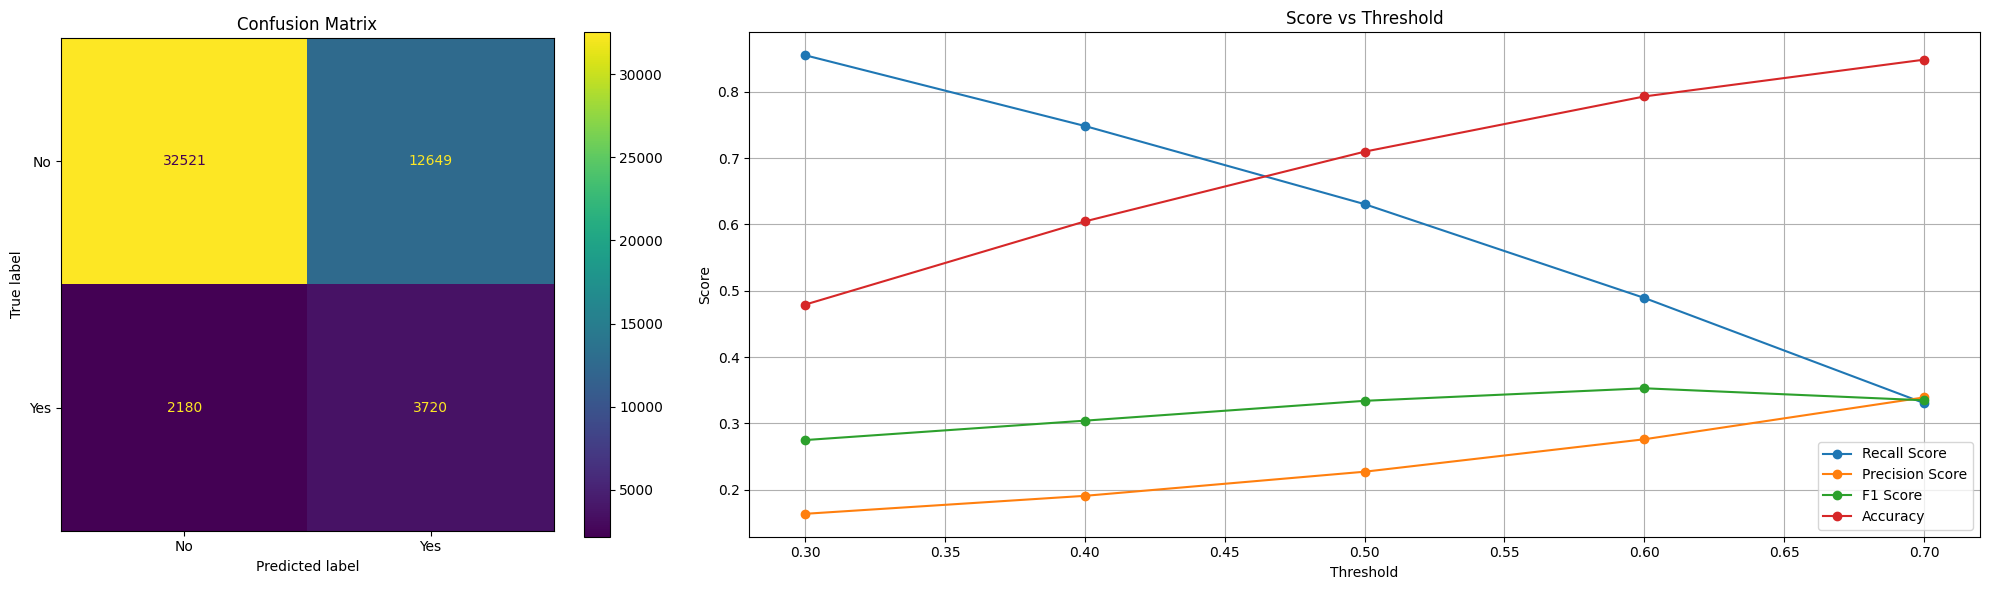

,Score,Percentage
0,Training Accuracy,73.94%
1,Test Accuracy,70.96%
2,Recall Score,33.07%
3,Precision Score,33.92%
4,Accuracy Score,84.83%
5,F1 Score,33.49%
6,ROC AUC Score,67.52%


In [119]:
scores_df, threshold_df = print_evaluation(model, X_train, y_train, X_test, y_test)
scores_df

In [120]:
threshold_df

,recall,precision,f1-score,accuracy
0.300,0.855,0.164,0.275,0.479
0.400,0.748,0.191,0.304,0.605
0.500,0.631,0.227,0.334,0.710
0.600,0.489,0.276,0.353,0.793
0.700,0.331,0.339,0.335,0.848
